# AFT threshold scan and protocol comparison

Run: `20260926T072423.208286Z_d9dd0e5f07`. All results are for the Z basis. Logical error rate is `errors / valid`; shaded regions and error bars are 95% Wilson intervals. A threshold requires evidence of a change in the distance trend or a crossing; the plotted p range alone cannot prove one. The two AFT variants are shown separately. Here cycles=d, so distance and circuit duration change together; this scan is indicative and is not a controlled threshold estimate at a fixed logical workload.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from knill_bench.analysis.plotting import load_logical_error_rates, save_figure

run = Path("../results/20260926T072423.208286Z_d9dd0e5f07")
rows = load_logical_error_rates(run)
assert len(rows) == 64
out = run / "plots"


## AFT: distance dependence against physical error rate

Each panel keeps the protocol fixed and compares distances at the same p. A downward triangle marks a zero-error observation **at its Wilson upper bound**, rather than placing a zero estimate on a logarithmic axis. The line is interrupted at those observations.


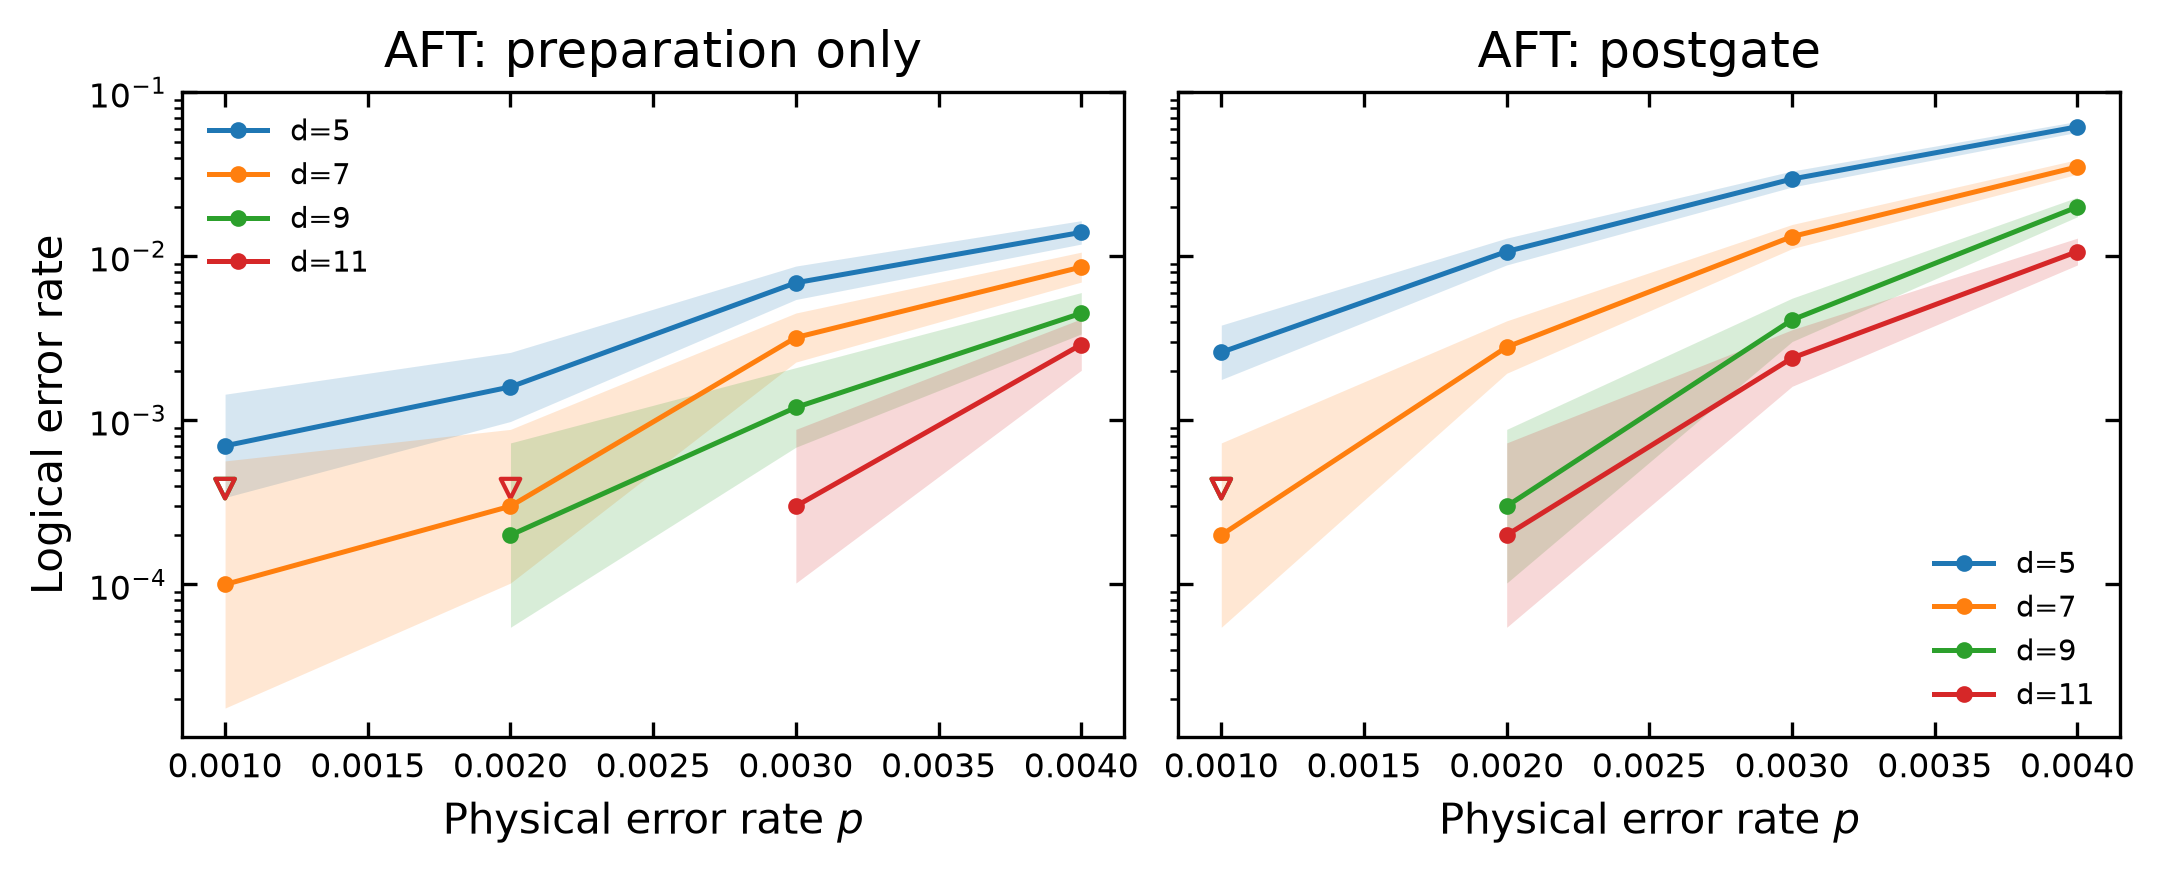

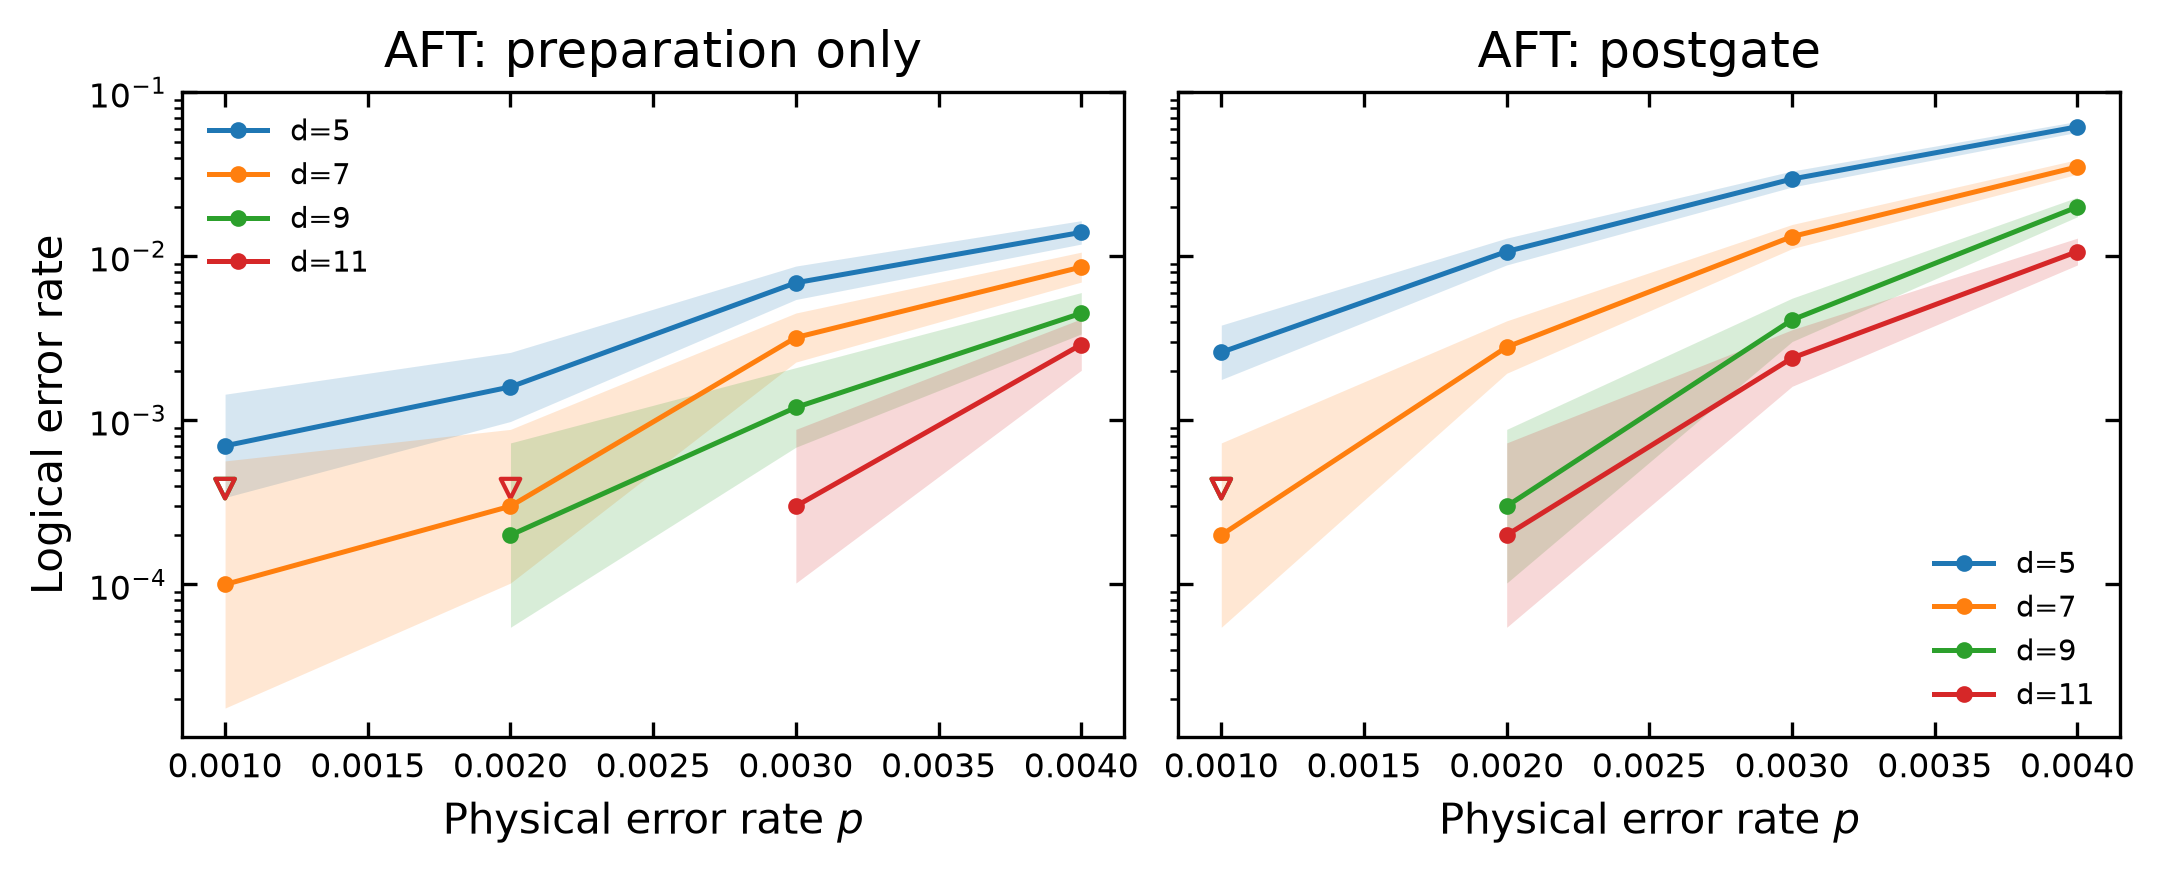

In [2]:
aft_protocols = (
    ("knill_aft_prep_only", "AFT: preparation only"),
    ("knill_aft_postgate", "AFT: postgate"),
)
fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.8), dpi=300,
                         layout="constrained", sharey=True)
for ax, (protocol, title) in zip(axes, aft_protocols):
    for distance in (5, 7, 9, 11):
        series = sorted((r for r in rows if r["protocol"] == protocol
                         and r["basis"] == "z" and r["distance"] == distance
                         and r["cycles"] == distance), key=lambda r: r["p"])
        assert len(series) == 4, (protocol, distance, len(series))
        x = np.array([r["p"] for r in series])
        y = np.array([r["ler"] if r["errors"] else np.nan for r in series])
        low = np.array([r["ci_low"] if r["errors"] else np.nan for r in series])
        high = np.array([r["ci_high"] if r["errors"] else np.nan for r in series])
        line, = ax.plot(x, y, "o-", linewidth=1.2, markersize=3,
                        label=f"d={distance}")
        ax.fill_between(x, low, high, color=line.get_color(), alpha=0.18,
                        linewidth=0)
        zero = [r for r in series if r["errors"] == 0]
        if zero:
            ax.scatter([r["p"] for r in zero], [r["ci_high"] for r in zero],
                       marker="v", s=22, facecolors="none",
                       edgecolors=line.get_color(), linewidths=1)
    ax.set(xlabel="Physical error rate $p$", title=title, yscale="log")
    ax.tick_params(labelsize=8, direction="in", top=True, right=True)
    ax.legend(fontsize=7, frameon=False)
axes[0].set_ylabel("Logical error rate")
save_figure(fig, out / "aft_distance_scan.pdf")
save_figure(fig, out / "aft_distance_scan.png")
fig


## Distance-trend check

The table below compares d=5 and d=11 at each measured p. A positive point-estimate reduction at every sampled p is compatible with operation below a threshold, but gives no threshold location. Wilson intervals should be considered when judging differences.


In [3]:
for protocol, title in aft_protocols:
    print(title)
    for p in sorted({r["p"] for r in rows}):
        small = next(r for r in rows if r["protocol"] == protocol
                     and r["distance"] == 5 and r["p"] == p)
        large = next(r for r in rows if r["protocol"] == protocol
                     and r["distance"] == 11 and r["p"] == p)
        print(f"  p={p:.3f}: d=5 {small['errors']}/{small['valid']}; "
              f"d=11 {large['errors']}/{large['valid']}; "
              f"d=11 lower point estimate: {large['ler'] < small['ler']}")


AFT: preparation only
  p=0.001: d=5 7/10000; d=11 0/10000; d=11 lower point estimate: True
  p=0.002: d=5 16/10000; d=11 0/10000; d=11 lower point estimate: True
  p=0.003: d=5 69/10000; d=11 3/10000; d=11 lower point estimate: True
  p=0.004: d=5 140/10000; d=11 29/10000; d=11 lower point estimate: True
AFT: postgate
  p=0.001: d=5 26/10000; d=11 0/10000; d=11 lower point estimate: True
  p=0.002: d=5 107/10000; d=11 2/10000; d=11 lower point estimate: True
  p=0.003: d=5 296/10000; d=11 24/10000; d=11 lower point estimate: True
  p=0.004: d=5 616/10000; d=11 107/10000; d=11 lower point estimate: True


## Fixed-parameter comparison

Fix `basis=z`, `distance=5`, `cycles=5`, and `p=0.003`. SE memory uses MWPM, Knill Hex uses its native pipeline, and both AFT variants use LOM. Decoder is therefore part of each evaluated method; this figure does not isolate the effect of the protocol alone.


Memory SE: 21/10000 = 0.0021, 95% Wilson [0.001374, 0.003208], decoder=mwpm, failed=0
AFT prep only: 69/10000 = 0.0069, 95% Wilson [0.005456, 0.008722], decoder=lom, failed=0
Knill: 272/10000 = 0.0272, 95% Wilson [0.02419, 0.03057], decoder=hex_native, failed=0
AFT postgate: 296/10000 = 0.0296, 95% Wilson [0.02645, 0.03311], decoder=lom, failed=0


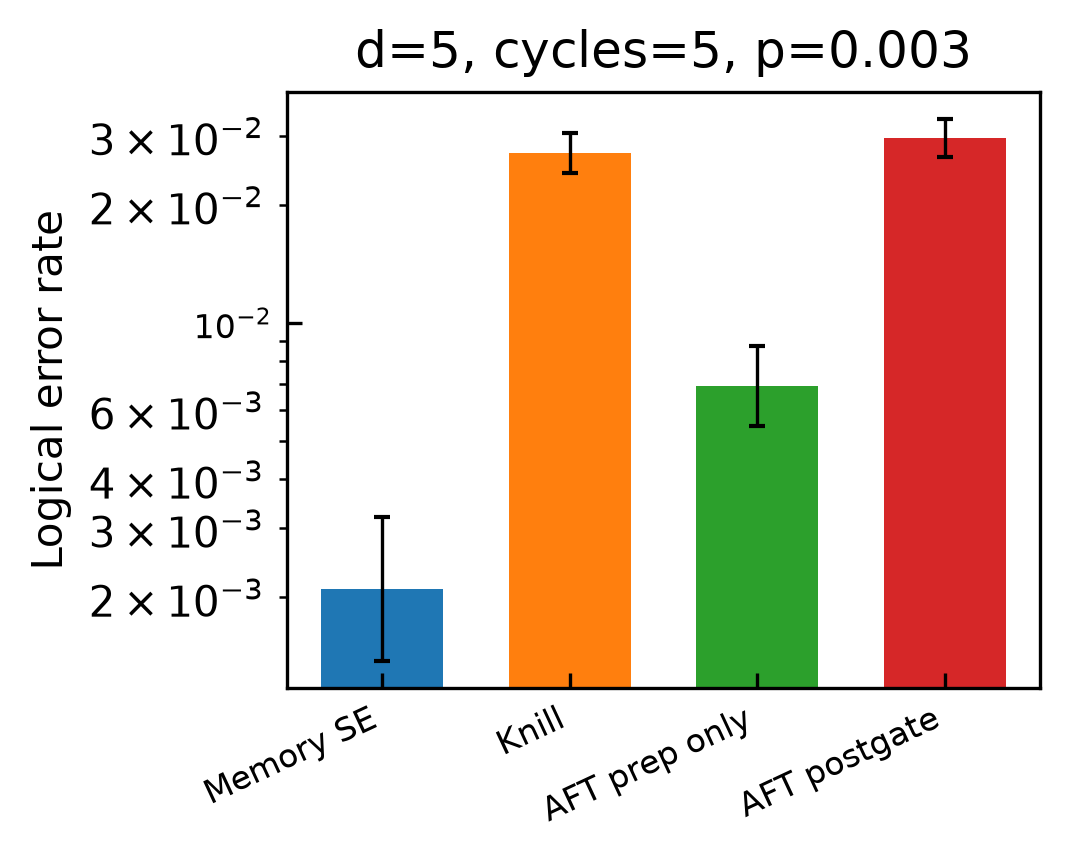

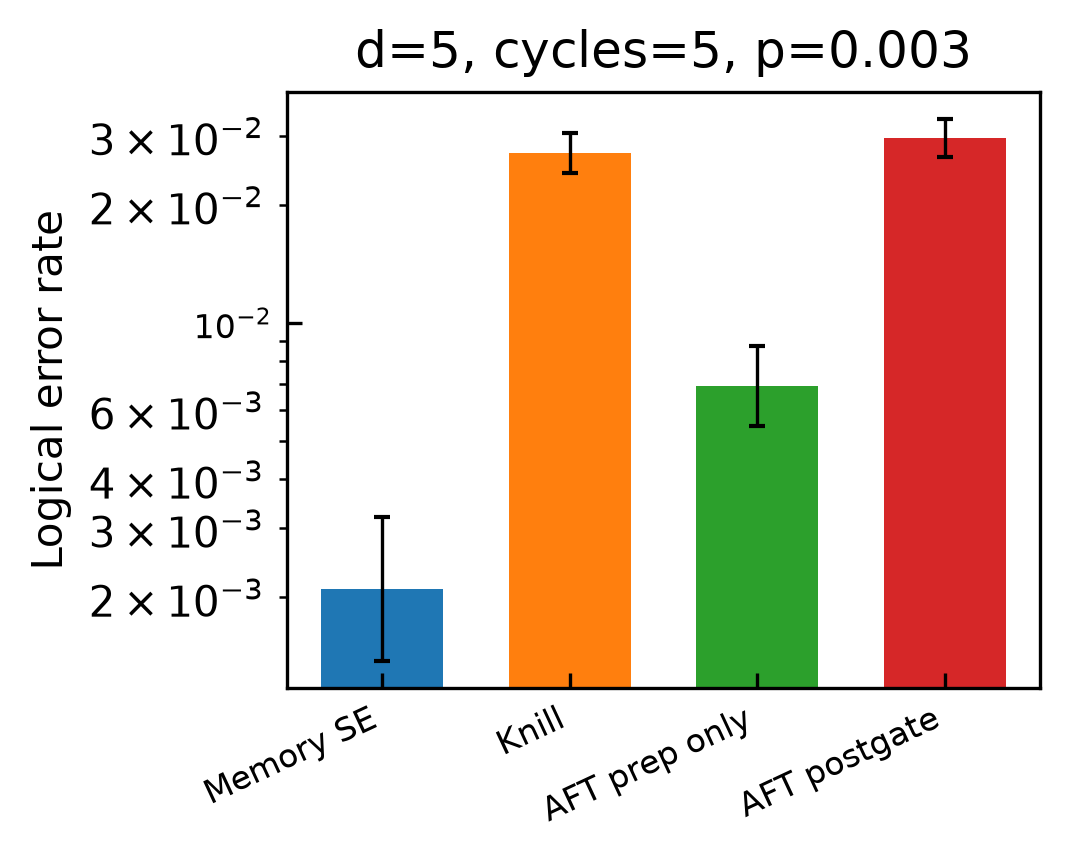

In [4]:
fixed = {"basis": "z", "distance": 5, "cycles": 5, "p": 0.003}
methods = (
    ("se_memory", "Memory SE"),
    ("knill_hex_dminus2", "Knill"),
    ("knill_aft_prep_only", "AFT prep only"),
    ("knill_aft_postgate", "AFT postgate"),
)
selected = []
for protocol, label in methods:
    matches = [r for r in rows if r["protocol"] == protocol
               and all(r[k] == v for k, v in fixed.items())]
    assert len(matches) == 1, (protocol, len(matches))
    selected.append((label, matches[0]))

fig, ax = plt.subplots(figsize=(3.45, 2.75), dpi=300, layout="constrained")
x = np.arange(len(selected))
y = np.array([r["ler"] for _, r in selected])
low = np.array([r["ci_low"] for _, r in selected])
high = np.array([r["ci_high"] for _, r in selected])
ax.bar(x, y, width=0.65, color=plt.get_cmap("tab10").colors[:len(x)])
ax.errorbar(x, y, yerr=[y-low, high-y], fmt="none", ecolor="black",
            capsize=2, linewidth=0.8)
ax.set_xticks(x, [label for label, _ in selected], rotation=25, ha="right")
ax.set(ylabel="Logical error rate", yscale="log",
       title="d=5, cycles=5, p=0.003")
ax.tick_params(labelsize=8, direction="in")
save_figure(fig, out / "fixed_method_comparison.pdf")
save_figure(fig, out / "fixed_method_comparison.png")
for label, r in sorted(selected, key=lambda pair: pair[1]["ler"]):
    print(f"{label}: {r['errors']}/{r['valid']} = {r['ler']:.4g}, "
          f"95% Wilson [{r['ci_low']:.4g}, {r['ci_high']:.4g}], "
          f"decoder={r['requested_decoder']}, failed={r['failed']}")
fig
